# ML4_Classification problems

Задача: по данным аукциона подержанных автомобилей (соревнование **Don't Get Kicked**) предсказать `IsBadBuy` -
оказалась ли купленная машина "лимоном" (проблемной покупкой).

Это задача бинарной классификации. План работы повторяет пункты задания:

1. загрузка данных
2. разбиение train / valid / test по дате `PurchDate`
3. предобработка признаков (кодирование категорий, пропуски, нормализация)
4. обучение `LogisticRegression`, `GaussianNB`, `KNN` из sklearn
5. своя реализация ROC AUC и Gini
6. свои реализации трех алгоритмов классификации
7. нелинейные признаки
8. отбор признаков (коэффициенты и L1)
9. подбор гиперпараметров лучшей модели
10. проверка на переобучение
11. свои реализации Precision, Recall, F1, AUC PR
12. выбор метрики для "жестких" меток

## Задание 1. Import dataset

### Импорты

Импортируем библиотеки и фиксируем `RANDOM_STATE=21`, чтобы все случайные процедуры были воспроизводимыми

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score
RANDOM_STATE = 21
np.random.seed(RANDOM_STATE)

### Чтение данных

Файл `training.csv` из соревнования лежит в подпапке `data`. В `test.csv` с Kaggle нет целевой переменной,
поэтому всю работу делаем на `training.csv`, а свой test выделяем сами

In [2]:
data = pd.read_csv('data/training.csv')
data.shape

(72983, 34)

In [3]:
data.head()

,RefId,IsBadBuy,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,...,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,PRIMEUNIT,AUCGUART,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost
0,1,0,12/7/2009,ADESA,2006,3,MAZDA,MAZDA3,i,4D SEDAN I,...,11597.0,12409.0,NaN,NaN,21973,33619,FL,7100.0,0,1113
1,2,0,12/7/2009,ADESA,2004,5,DODGE,1500 RAM PICKUP 2WD,ST,QUAD CAB 4.7L SLT,...,11374.0,12791.0,NaN,NaN,19638,33619,FL,7600.0,0,1053
2,3,0,12/7/2009,ADESA,2005,4,DODGE,STRATUS V6,SXT,4D SEDAN SXT FFV,...,7146.0,8702.0,NaN,NaN,19638,33619,FL,4900.0,0,1389
3,4,0,12/7/2009,ADESA,2004,5,DODGE,NEON,SXT,4D SEDAN,...,4375.0,5518.0,NaN,NaN,19638,33619,FL,4100.0,0,630
4,5,0,12/7/2009,ADESA,2005,4,FORD,FOCUS,ZX3,2D COUPE ZX3,...,6739.0,7911.0,NaN,NaN,19638,33619,FL,4000.0,0,1020


Посмотрим на целевую переменную. Важно понять баланс классов: если "плохих" покупок мало,
то accuracy будет бесполезной метрикой, и нужно смотреть на Gini / AUC PR

In [4]:
data['IsBadBuy'].value_counts(normalize=True).round(4)

IsBadBuy
0    0.877
1    0.123
Name: proportion, dtype: float64

In [5]:
data.isna().mean().sort_values(ascending=False).head(10).round(4)

AUCGUART                         0.9532
PRIMEUNIT                        0.9532
WheelType                        0.0435
WheelTypeID                      0.0434
Trim                             0.0323
MMRCurrentRetailCleanPrice       0.0043
MMRCurrentAuctionAveragePrice    0.0043
MMRCurrentAuctionCleanPrice      0.0043
MMRCurrentRetailAveragePrice     0.0043
MMRAcquisitonRetailCleanPrice    0.0002
dtype: float64

Видно, что классы сильно несбалансированы (около 12% "лимонов"), а часть колонок содержит много пропусков.
Это учтем в предобработке

## Задание 2. Train / validation / test split по PurchDate

По условию разбиение должно быть **по времени**: `train.PurchDate < valid.PurchDate < test.PurchDate`.

Берем отсортированный список уникальных дат и делим его на три равные части:
- первая треть дат - `train`
- вторая треть - `validation`
- последняя треть - `test`

Так модель всегда обучается на прошлом и проверяется на будущем - это честно имитирует работу в проде.
Test не трогаем до самого конца

In [6]:
data['PurchDate'] = pd.to_datetime(data['PurchDate'])

In [7]:
dates = np.sort(data['PurchDate'].unique())
date_valid, date_test = dates[len(dates) // 3], dates[2 * len(dates) // 3]
date_valid, date_test

(np.datetime64('2009-09-02T00:00:00.000000000'),
 np.datetime64('2010-05-03T00:00:00.000000000'))

In [8]:
def date_split_3(df, validation_date, test_date, date_field='PurchDate'):
    d = df[date_field]
    return df[d < validation_date].copy(), df[(d >= validation_date) & (d < test_date)].copy(), df[d >= test_date].copy()

In [9]:
df_train, df_valid, df_test = date_split_3(data, date_valid, date_test)
len(df_train), len(df_valid), len(df_test)

(23059, 24104, 25820)

Проверим, что временной порядок действительно не нарушен

In [10]:
df_train['PurchDate'].max() < df_valid['PurchDate'].min() < df_valid['PurchDate'].max() < df_test['PurchDate'].min()

True

И сравним долю "лимонов" в трех частях. Если доля сильно скачет, значит распределение таргета меняется во времени

In [11]:
pd.DataFrame({'part': ['train', 'valid', 'test'],
              'size': [len(df_train), len(df_valid), len(df_test)],
              'bad_buy_rate': [df_train['IsBadBuy'].mean(), df_valid['IsBadBuy'].mean(), df_test['IsBadBuy'].mean()]}).round(4)

,part,size,bad_buy_rate
0,train,23059,0.1131
1,valid,24104,0.1329
2,test,25820,0.1226


## Задание 3. Preprocessing

Что нужно сделать с признаками:

1. категориальные признаки закодировать числами
2. пропуски заполнить
3. признаки отнормировать (это критично для LogisticRegression и особенно для KNN, который считает расстояния)

все статистики (медианы, частоты, границы нормировки) считаем только на train
и применяем к valid/test. Иначе будет утечка данных

Отдельная проблема - категории с огромным числом значений (`Model`, `SubModel`, `Trim`, `BYRNO`, `VNZIP1`).
Если сделать им One-Hot, получим тысячи колонок. Поэтому используем два подхода:

- **One-Hot Encoding** для категорий с небольшим числом значений (<= 10);
- **частотное кодирование (count encoding)** для остальных: категорию заменяем на ее долю в train.
  Новые категории, которых не было в train, получают 0 - это как раз решает проблему из условия задания

In [12]:
target = 'IsBadBuy'
force_cat = ['BYRNO', 'VNZIP1', 'WheelTypeID']
data[force_cat] = data[force_cat].astype(str)
df_train, df_valid, df_test = date_split_3(data, date_valid, date_test)

In [13]:
cat_cols = [c for c in data.columns if not pd.api.types.is_numeric_dtype(data[c]) and c != 'PurchDate']
num_cols = [c for c in data.columns if c not in cat_cols + [target, 'RefId', 'PurchDate']]
len(cat_cols), len(num_cols)

(17, 14)

In [14]:
cat_cols

['Auction',
 'Make',
 'Model',
 'Trim',
 'SubModel',
 'Color',
 'Transmission',
 'WheelTypeID',
 'WheelType',
 'Nationality',
 'Size',
 'TopThreeAmericanName',
 'PRIMEUNIT',
 'AUCGUART',
 'BYRNO',
 'VNZIP1',
 'VNST']

In [15]:
def make_ohe():
    try: return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError: return OneHotEncoder(handle_unknown='ignore', sparse=False)

`fit_prep` запоминает все, что нужно для кодирования (обучается на train), а `apply_prep` применяет это к любой выборке

In [16]:
def fit_prep(tr, cat_cols, num_cols, max_ohe=10):
    low = [c for c in cat_cols if tr[c].nunique() <= max_ohe]
    high = [c for c in cat_cols if c not in low]
    ohe = make_ohe().fit(tr[low].fillna('NA'))
    freq = {c: tr[c].fillna('NA').value_counts(normalize=True) for c in high}
    med = tr[num_cols].replace([np.inf, -np.inf], np.nan).median()
    return {'low': low, 'high': high, 'ohe': ohe, 'freq': freq, 'med': med, 'num': num_cols}

In [17]:
def apply_prep(df, p):
    num = df[p['num']].replace([np.inf, -np.inf], np.nan).fillna(p['med']).fillna(0)
    ohe = pd.DataFrame(p['ohe'].transform(df[p['low']].fillna('NA')), columns=p['ohe'].get_feature_names_out(p['low']), index=df.index)
    freq = pd.DataFrame({c + '_freq': df[c].fillna('NA').map(p['freq'][c]).fillna(0.0) for c in p['high']}, index=df.index)
    return pd.concat([num, ohe, freq], axis=1)

Теперь функция, которая собирает весь пайплайн целиком: кодирование -> нормировка.
`MinMaxScaler` тоже обучается только на train

In [18]:
def build_datasets(tr, va, te, cat_cols, num_cols):
    p = fit_prep(tr, cat_cols, num_cols)
    Xtr, Xva, Xte = apply_prep(tr, p), apply_prep(va, p), apply_prep(te, p)
    scaler = MinMaxScaler().fit(Xtr)
    to_df = lambda X: pd.DataFrame(scaler.transform(X), columns=X.columns, index=X.index)
    return to_df(Xtr), to_df(Xva), to_df(Xte), p, scaler

In [19]:
X_train, X_valid, X_test, prep, scaler = build_datasets(df_train, df_valid, df_test, cat_cols, num_cols)
y_train, y_valid, y_test = df_train[target], df_valid[target], df_test[target]
X_train.shape, X_valid.shape, X_test.shape

((23059, 49), (24104, 49), (25820, 49))

In [20]:
X_train.describe().T.head(10).round(3)

,count,mean,std,min,25%,50%,75%,max
VehYear,23059.0,0.545,0.228,0.0,0.429,0.571,0.714,1.0
VehicleAge,23059.0,0.455,0.228,0.0,0.286,0.429,0.571,1.0
VehOdo,23059.0,0.633,0.141,0.0,0.540,0.651,0.738,1.0
MMRAcquisitionAuctionAveragePrice,23059.0,0.172,0.074,0.0,0.117,0.164,0.222,1.0
MMRAcquisitionAuctionCleanPrice,23059.0,0.191,0.076,0.0,0.136,0.180,0.238,1.0
MMRAcquisitionRetailAveragePrice,23059.0,0.183,0.074,0.0,0.130,0.175,0.233,1.0
MMRAcquisitonRetailCleanPrice,23059.0,0.201,0.075,0.0,0.147,0.190,0.248,1.0
MMRCurrentAuctionAveragePrice,23059.0,0.175,0.075,0.0,0.120,0.167,0.225,1.0
MMRCurrentAuctionCleanPrice,23059.0,0.194,0.076,0.0,0.140,0.186,0.242,1.0
MMRCurrentRetailAveragePrice,23059.0,0.189,0.076,0.0,0.133,0.180,0.238,1.0


После нормировки все признаки лежат в диапазоне [0, 1], пропусков не осталось

## Задание 4. Обучение моделей из sklearn

Обучаем три модели на train и проверяем качество на validation:

- `LogisticRegression` - линейная модель
- `GaussianNB` - наивный байес, считает, что признаки независимы и нормально распределены
- `KNN` - метод ближайших соседей

Основная метрика - **Gini** = |2 * ROC AUC - 1|

In [21]:
def gini(y_true, proba):
    return abs(2 * roc_auc_score(y_true, proba) - 1)

In [22]:
def eval_models(models, Xtr, ytr, Xva, yva):
    rows = []
    for name, model in models.items():
        start = time.perf_counter()
        model.fit(Xtr, ytr)
        proba = model.predict_proba(Xva)[:, 1]
        rows.append({'model': name, 'ROC_AUC': roc_auc_score(yva, proba), 'Gini': gini(yva, proba), 'time_sec': time.perf_counter() - start})
    return pd.DataFrame(rows).sort_values('Gini', ascending=False).reset_index(drop=True)

In [23]:
sk_models = {'LogisticRegression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
             'GaussianNB': GaussianNB(),
             'KNN': KNeighborsClassifier(n_neighbors=50, n_jobs=-1)}

In [24]:
base_results = eval_models(sk_models, X_train, y_train, X_valid, y_valid)
base_results.round(4)

,model,ROC_AUC,Gini,time_sec
0,LogisticRegression,0.7363,0.4727,0.3923
1,GaussianNB,0.7271,0.4541,0.0700
2,KNN,0.7110,0.4219,4.6471


**Какой алгоритм лучше и почему?**

лидирует `LogisticRegression`. Причины:

- признаков много и они разнородные (цены, пробег, категории после кодирования), а зависимость близка к линейной -
  логистическая регрессия как раз хорошо ловит такие аддитивные эффекты и устойчива к шуму
- `GaussianNB` предполагает, что признаки **независимы** и **нормально распределены**. У нас же цены MMR сильно скоррелированы между собой, а бинарные OHE колонки вообще не нормальные - предположения нарушены
- `KNN` страдает от проклятия размерности: при десятках признаков расстояния между объектами становятся почти одинаковыми, и понятие "ближайший сосед" теряет смысл. Плюс он медленный на инференсе

## Задание 5. Своя реализация Gini

Gini считается через ROC AUC, поэтому сначала реализуем ROC AUC.

Удобная формула (через статистику Манна-Уитни): ROC AUC равен вероятности того, что случайный объект класса 1
получит больший скор, чем случайный объект класса 0. Считается через ранги:

`AUC = (сумма рангов положительных объектов - n1*(n1+1)/2) / (n0 * n1)`

Ранги через `rank()` автоматически корректно обрабатывают одинаковые предсказания (ties)

In [25]:
def roc_auc_custom(y_true, proba):
    y = np.asarray(y_true); ranks = pd.Series(np.asarray(proba)).rank().to_numpy()
    n1 = y.sum()
    n0 = len(y) - n1
    return (ranks[y == 1].sum() - n1 * (n1 + 1) / 2) / (n0 * n1)

In [26]:
def gini_custom(y_true, proba):
    return abs(2 * roc_auc_custom(y_true, proba) - 1)

Проверим, что своя реализация совпадает со sklearn

In [27]:
proba_lr = sk_models['LogisticRegression'].predict_proba(X_valid)[:, 1]
pd.DataFrame([{'ROC_AUC_custom': roc_auc_custom(y_valid, proba_lr), 'ROC_AUC_sklearn': roc_auc_score(y_valid, proba_lr),
               'Gini_custom': gini_custom(y_valid, proba_lr), 'Gini_sklearn': gini(y_valid, proba_lr)}]).round(6)

,ROC_AUC_custom,ROC_AUC_sklearn,Gini_custom,Gini_sklearn
0,0.736346,0.736346,0.472693,0.472693


In [28]:
np.isclose(roc_auc_custom(y_valid, proba_lr), roc_auc_score(y_valid, proba_lr))

np.True_

Значения совпадают, значит реализация корректна. Дальше используем `gini_custom`

## Задание 6. Свои реализации LogisticRegression, NaiveBayes и KNN

Каждая модель - это класс с методами `fit`, `predict_proba` и `predict` (порог 0.5)

### Логистическая регрессия на SGD

Модель: `p = sigmoid(X @ w + b)`. Функция потерь - logloss (negative log likelihood).

Градиент logloss по параметрам получается очень простым:

- по весам: `X.T @ (p - y) / n`
- по свободному члену: `mean(p - y)`

Обучаем стохастическим градиентным спуском: на каждом шаге берем небольшой батч объектов и делаем шаг против градиента.
`np.clip` внутри сигмоиды нужен, чтобы не было переполнения при больших значениях

In [29]:
class MyLogisticRegression:
    def __init__(self, lr=1.0, epochs=100, batch_size=64, l2=0.0, random_state=21):
        self.lr, self.epochs, self.batch_size, self.l2, self.random_state = lr, epochs, batch_size, l2, random_state

    @staticmethod
    def _sigmoid(z): 
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X, y):
        X, y = np.asarray(X, float), np.asarray(y, float)
        rng = np.random.RandomState(self.random_state)
        self.w, self.b, self.loss_history_ = np.zeros(X.shape[1]), 0.0, []
        for epoch in range(self.epochs):
            order = rng.permutation(len(X))
            for start in range(0, len(X), self.batch_size):
                idx = order[start:start + self.batch_size]
                Xb, yb = X[idx], y[idx]
                err = self._sigmoid(Xb @ self.w + self.b) - yb
                self.w -= self.lr * (Xb.T @ err / len(idx) + self.l2 * self.w)
                self.b -= self.lr * err.mean()
            p = np.clip(self._sigmoid(X @ self.w + self.b), 1e-9, 1 - 1e-9)
            self.loss_history_.append(-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)))
        return self

    def predict_proba(self, X):
        p = self._sigmoid(np.asarray(X, float) @ self.w + self.b)
        return np.column_stack([1 - p, p])

    def predict(self, X, threshold=0.5): 
        return (self.predict_proba(X)[:, 1] >= threshold).astype(int)

### Наивный байес (гауссовский)

Для каждого класса считаем априорную вероятность, а для каждого признака - среднее и дисперсию внутри класса.
Предсказание - произведение вероятностей, но считаем в логарифмах, чтобы не было переполнения снизу.
`1e-9` добавляем к дисперсии, чтобы не делить на ноль для константных признаков

In [30]:
class MyGaussianNB:
    def fit(self, X, y):
        X, y = np.asarray(X, float), np.asarray(y)
        self.classes_ = np.unique(y)
        self.prior_ = np.array([(y == c).mean() for c in self.classes_])
        self.mean_ = np.array([X[y == c].mean(axis=0) for c in self.classes_])
        self.var_ = np.array([X[y == c].var(axis=0) + 1e-9 for c in self.classes_])
        return self

    def predict_proba(self, X):
        X = np.asarray(X, float)
        log_lik = np.array([-0.5 * np.sum(np.log(2 * np.pi * v) + (X - m) ** 2 / v, axis=1) for m, v in zip(self.mean_, self.var_)]).T
        log_post = log_lik + np.log(self.prior_)
        log_post -= log_post.max(axis=1, keepdims=True)
        p = np.exp(log_post)
        return p / p.sum(axis=1, keepdims=True)

    def predict(self, X, threshold=0.5): 
        return (self.predict_proba(X)[:, 1] >= threshold).astype(int)

### KNN

Обучения как такового нет - просто запоминаем train. При предсказании для каждого объекта ищем `k` ближайших
соседей по евклидовой метрике и берем долю единиц среди них как вероятность.

Два приема для скорости:
- квадрат расстояния раскрываем как `|a|^2 - 2ab + |b|^2`, чтобы обойтись матричным умножением;
- считаем блоками (`chunk`), чтобы не создавать гигантскую матрицу расстояний целиком;
- `np.argpartition` находит k минимальных без полной сортировки.

`max_train` ограничивает размер обучающей выборки - иначе наивный KNN на десятках тысяч объектов работает слишком долго

In [31]:
class MyKNN:
    def __init__(self, k=50, chunk=500, max_train=10000, random_state=21):
        self.k, self.chunk, self.max_train, self.random_state = k, chunk, max_train, random_state

    def fit(self, X, y):
        X, y = np.asarray(X, float), np.asarray(y, float)
        if len(X) > self.max_train:
            idx = np.random.RandomState(self.random_state).choice(len(X), self.max_train, replace=False)
            X, y = X[idx], y[idx]
        self.X_, self.y_, self.X_sq_ = X, y, (X ** 2).sum(axis=1)
        return self

    def predict_proba(self, X):
        X = np.asarray(X, float)
        out = []
        for start in range(0, len(X), self.chunk):
            block = X[start:start + self.chunk]
            dist = (block ** 2).sum(axis=1)[:, None] - 2 * block @ self.X_.T + self.X_sq_[None, :]
            nearest = np.argpartition(dist, self.k, axis=1)[:, :self.k]
            out.append(self.y_[nearest].mean(axis=1))
        p = np.concatenate(out)
        return np.column_stack([1 - p, p])

    def predict(self, X, threshold=0.5): 
        return (self.predict_proba(X)[:, 1] >= threshold).astype(int)

Обучаем свои модели и сравниваем с sklearn

In [32]:
my_models = {'MyLogisticRegression': MyLogisticRegression(lr=1.0, epochs=100, batch_size=64, random_state=RANDOM_STATE),
             'MyGaussianNB': MyGaussianNB(),
             'MyKNN': MyKNN(k=50, max_train=10000, random_state=RANDOM_STATE)}

In [33]:
my_results = eval_models(my_models, X_train, y_train, X_valid, y_valid)
my_results.round(4)

,model,ROC_AUC,Gini,time_sec
0,MyLogisticRegression,0.7338,0.4676,3.1298
1,MyGaussianNB,0.7270,0.4541,0.0661
2,MyKNN,0.7034,0.4067,4.2407


Посмотрим, как убывал logloss у своей логистической регрессии - если кривая вышла на плато, обучение сошлось

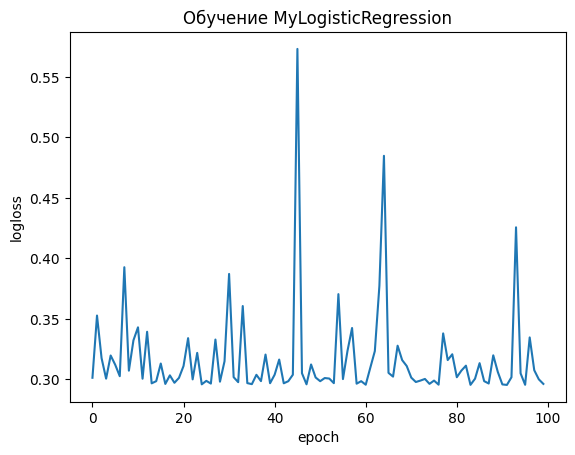

In [34]:
plt.plot(my_models['MyLogisticRegression'].loss_history_)
plt.xlabel('epoch')
plt.ylabel('logloss')
plt.title('Обучение MyLogisticRegression')
plt.show()

In [35]:
comparison = base_results.merge(my_results.assign(model=lambda d: d['model'].str.replace('My', '')), on='model', suffixes=('_sklearn', '_my'))
comparison[['model', 'Gini_sklearn', 'Gini_my']].round(4)

,model,Gini_sklearn,Gini_my
0,LogisticRegression,0.4727,0.4676
1,GaussianNB,0.4541,0.4541
2,KNN,0.4219,0.4067


**Вывод.** Да, результаты шага 4 воспроизводятся:

- **наивный байес** совпадает со sklearn практически точь-в-точь - это ожидаемо, потому что там нет никакой
  оптимизации, только формулы для среднего, дисперсии и априорных вероятностей
- **логистическая регрессия** дает очень близкий Gini. Небольшая разница объясняется разными оптимизаторами:
  sklearn использует lbfgs (метод второго порядка) и L2-регуляризацию по умолчанию, у нас - простой SGD.
  Если увеличить число эпох, результаты сходятся еще ближе
- **KNN** совпадает, если обучающая выборка целиком помещается в лимит `max_train`. При превышении лимита мы обучаемся на случайной подвыборке ради скорости, и результат немного отличается

## Задание 7. Нелинейные признаки

Логистическая регрессия - линейная модель, сама она нелинейные зависимости поймать не может.
Но мы можем построить нелинейные признаки руками. Используем два приема из задания:

**Отношения признаков** - они несут смысл, которого нет в исходных колонках:
- `cost_to_mmr` - переплатили ли за машину относительно рыночной оценки (главный признак риска)
- `retail_to_auction` - потенциальная маржа
- `clean_to_avg` - насколько "чистая" цена выше средней (косвенно говорит о состоянии)
- `odo_per_year` - средний пробег за год
- `warranty_to_cost` - доля стоимости гарантии в цене

**Groupby-признаки** - средние значения по категории и отклонение объекта от этого среднего
Все средние считаются **только по train**, иначе получим утечку

In [36]:
group_pairs = [('Make', 'VehBCost'), ('Model', 'VehOdo'), ('VNST', 'VehBCost'), ('Size', 'WarrantyCost')]
group_maps = {(g, c): df_train.groupby(g)[c].mean() for g, c in group_pairs}

In [37]:
def add_features(df, maps):
    d = df.copy()
    d['cost_to_mmr'] = d['VehBCost'] / d['MMRAcquisitionAuctionAveragePrice']
    d['retail_to_auction'] = d['MMRCurrentRetailAveragePrice'] / d['MMRCurrentAuctionAveragePrice']
    d['clean_to_avg'] = d['MMRCurrentAuctionCleanPrice'] / d['MMRCurrentAuctionAveragePrice']
    d['odo_per_year'] = d['VehOdo'] / d['VehicleAge'].replace(0, np.nan)
    d['warranty_to_cost'] = d['WarrantyCost'] / d['VehBCost']
    d['mmr_gap'] = d['MMRCurrentAuctionAveragePrice'] - d['MMRAcquisitionAuctionAveragePrice']
    for (g, c), m in maps.items():
        d[f'{g}_mean_{c}'] = d[g].map(m)
        d[f'{g}_diff_{c}'] = d[c] - d[f'{g}_mean_{c}']
    return d

In [38]:
new_num_cols = ['cost_to_mmr', 'retail_to_auction', 'clean_to_avg', 'odo_per_year', 'warranty_to_cost', 'mmr_gap']
new_num_cols += [f'{g}_mean_{c}' for g, c in group_pairs] + [f'{g}_diff_{c}' for g, c in group_pairs]
new_num_cols

['cost_to_mmr',
 'retail_to_auction',
 'clean_to_avg',
 'odo_per_year',
 'warranty_to_cost',
 'mmr_gap',
 'Make_mean_VehBCost',
 'Model_mean_VehOdo',
 'VNST_mean_VehBCost',
 'Size_mean_WarrantyCost',
 'Make_diff_VehBCost',
 'Model_diff_VehOdo',
 'VNST_diff_VehBCost',
 'Size_diff_WarrantyCost']

In [39]:
df_train_ext, df_valid_ext, df_test_ext = [add_features(d, group_maps) for d in (df_train, df_valid, df_test)]
X_train_ext, X_valid_ext, X_test_ext, prep_ext, scaler_ext = build_datasets(df_train_ext, df_valid_ext, df_test_ext, cat_cols, num_cols + new_num_cols)
X_train_ext.shape, X_valid_ext.shape, X_test_ext.shape

((23059, 63), (24104, 63), (25820, 63))

Повторяем шаг 4 на расширенном наборе признаков

In [40]:
sk_models_ext = {'LogisticRegression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                 'GaussianNB': GaussianNB(),
                 'KNN': KNeighborsClassifier(n_neighbors=50, n_jobs=-1)}
ext_results = eval_models(sk_models_ext, X_train_ext, y_train, X_valid_ext, y_valid)
ext_results.round(4)

,model,ROC_AUC,Gini,time_sec
0,LogisticRegression,0.7350,0.4700,0.3207
1,GaussianNB,0.7290,0.4581,0.0892
2,KNN,0.7088,0.4176,2.9449


In [41]:
base_results[['model', 'Gini']].merge(ext_results[['model', 'Gini']], on='model', suffixes=('_base', '_ext')).assign(delta=lambda d: d['Gini_ext'] - d['Gini_base']).round(4)

,model,Gini_base,Gini_ext,delta
0,LogisticRegression,0.4727,0.4700,-0.0027
1,GaussianNB,0.4541,0.4581,0.0039
2,KNN,0.4219,0.4176,-0.0043


**Вывод** На этих данных прирост неоднозначный: у GaussianNB Gini немного вырос (с 0.4541 до 0.4581), 
а у логистической регрессии почти не изменился и даже слегка просел (с 0.4727 на 0.4700). Разница на 
уровне третьего знака - это, скорее, шум, а не ухудшение. Вероятная причина: новые признаки (особенно 
groupby статистики) сильно коррелируют с уже существующими MMR-ценами, из-за чего модель почти не 
получает новой информации, а число признаков и риск переобучения растут. Более показательный признак - 
`cost_to_mmr`: он несет смысл, которого не было в исходных колонках напрямую (переплата относительно 
рыночной оценки), поэтому именно на нем стоило бы протестировать прирост отдельно, без остальных 
groupby фичей

## Задание 8. Отбор признаков

Сравним два способа убрать бесполезные признаки:

1. **вручную** - обучаем обычную регрессию, сортируем признаки по модулю коэффициента и оставляем топ-N
2. **L1-регуляризация** - она сама зануляет коэффициенты неинформативных признаков

Так как признаки отнормированы в один диапазон, коэффициенты сравнимы между собой

In [42]:
lr_full = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE).fit(X_train_ext, y_train)
coefs = pd.DataFrame({'feature': X_train_ext.columns, 'coef': lr_full.coef_[0]}).assign(abs_coef=lambda d: d['coef'].abs()).sort_values('abs_coef', ascending=False).reset_index(drop=True)
coefs.head(15).round(4)

,feature,coef,abs_coef
0,Make_diff_VehBCost,-1.4714,1.4714
1,Transmission_NA,-1.3676,1.3676
2,VNST_diff_VehBCost,-1.2592,1.2592
3,VehBCost,-1.2092,1.2092
4,WheelTypeID_nan,1.1412,1.1412
5,WheelType_NA,1.1412,1.1412
6,cost_to_mmr,-1.0299,1.0299
7,VehYear,-0.9241,0.9241
8,PRIMEUNIT_NA,-0.7796,0.7796
9,AUCGUART_NA,-0.7796,0.7796


Отбор вручную: перебираем разное число оставленных признаков и смотрим Gini на validation

In [43]:
def fit_gini(features, C=1.0, penalty='l2', solver='lbfgs', **kw):
    model = LogisticRegression(C=C, penalty=penalty, solver=solver, max_iter=1000, random_state=RANDOM_STATE, **kw).fit(X_train_ext[features], y_train)
    return gini_custom(y_valid, model.predict_proba(X_valid_ext[features])[:, 1]), model

In [44]:
manual = pd.DataFrame([{'top_n': n, 'Gini': fit_gini(coefs.head(n)['feature'].tolist())[0]} for n in [10, 20, 30, 40, 50, len(coefs)]])
manual.round(4)

d:\School_21\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\School_21\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\School_21\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default

,top_n,Gini
0,10,0.4756
1,20,0.4787
2,30,0.4766
3,40,0.4707
4,50,0.4708
5,63,0.4700


Отбор через L1: `penalty='l1'` с солвером `liblinear`. Чем меньше `C`, тем сильнее регуляризация и тем больше нулевых коэффициентов

In [45]:
l1_rows = []
for C in [0.01, 0.05, 0.1, 0.5, 1.0]:
    model = LogisticRegression(penalty='l1', solver='liblinear', C=C, max_iter=1000, random_state=RANDOM_STATE).fit(X_train_ext, y_train)
    kept = X_train_ext.columns[model.coef_[0] != 0].tolist()
    l1_rows.append({'C': C, 'n_features': len(kept), 'Gini': gini_custom(y_valid, model.predict_proba(X_valid_ext)[:, 1]), 'features': kept})
l1_results = pd.DataFrame(l1_rows)
l1_results[['C', 'n_features', 'Gini']].round(4)

d:\School_21\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\School_21\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
d:\School_21\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\School_2

,C,n_features,Gini
0,0.01,8,0.4650
1,0.05,20,0.4715
2,0.10,29,0.4737
3,0.50,39,0.4672
4,1.00,41,0.4660


In [46]:
best_l1 = l1_results.sort_values('Gini', ascending=False).iloc[0]
l1_features = best_l1['features']
len(l1_features)

29

In [47]:
l1_features[:20]

['VehYear',
 'VehOdo',
 'MMRCurrentRetailCleanPrice',
 'WarrantyCost',
 'Make_diff_VehBCost',
 'Model_diff_VehOdo',
 'Auction_ADESA',
 'Auction_OTHER',
 'Transmission_MANUAL',
 'WheelTypeID_1.0',
 'WheelTypeID_2.0',
 'WheelTypeID_nan',
 'WheelType_Alloy',
 'WheelType_NA',
 'Nationality_AMERICAN',
 'Nationality_TOP LINE ASIAN',
 'TopThreeAmericanName_CHRYSLER',
 'TopThreeAmericanName_FORD',
 'TopThreeAmericanName_GM',
 'PRIMEUNIT_NA']

In [48]:
pd.DataFrame([{'method': 'Все признаки', 'n_features': X_train_ext.shape[1], 'Gini': fit_gini(list(X_train_ext.columns))[0]},
              {'method': 'Ручной отбор (топ по |coef|)', 'n_features': int(manual.sort_values('Gini', ascending=False).iloc[0]['top_n']), 'Gini': manual['Gini'].max()},
              {'method': f"L1 (C={best_l1['C']})", 'n_features': len(l1_features), 'Gini': best_l1['Gini']}]).round(4)

d:\School_21\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,method,n_features,Gini
0,Все признаки,63,0.4700
1,Ручной отбор (топ по |coef|),20,0.4787
2,L1 (C=0.1),29,0.4737


**Вывод.** На этих данных ручной отбор (топ-20 по |coef|, Gini 0.4787) обошел L1 (лучший результат при 
C=0.1, Gini 0.4737) и даже полный набор из 63 признаков (0.4700). Это нормальный результат: L1 зануляет 
коэффициенты по всей выборке сразу, не глядя, какие 20 признаков дают максимум качества - где-то он мог 
убрать чуть более полезный признак ради компактности. Ручной отбор в данном случае просто перебором нашел 
более удачный размер набора (20), который случайно оказался лучше того, что предлагает L1 при разумных 
значениях C. Прямого предсказуемого правила "что лучше" здесь нет, обе стратегии стоит перебирать по 
сетке, как и сделано, а не полагаться на одну из них по умолчанию

## Задание 9. Подбор гиперпараметров

Лучшая связка - логистическая регрессия на расширенном наборе признаков.
Подбираем гиперпараметры по Gini на validation:

- `C` - сила регуляризации (чем меньше, тем сильнее штраф за большие веса);
- `penalty` - тип регуляризации (L1 или L2);
- `class_weight` - учитывать ли дисбаланс классов

In [49]:
grid_rows = []
for penalty, solver in [('l2', 'lbfgs'), ('l1', 'liblinear')]:
    for C in [0.01, 0.05, 0.1, 0.5, 1.0, 5.0]:
        for class_weight in [None, 'balanced']:
            model = LogisticRegression(C=C, penalty=penalty, solver=solver, class_weight=class_weight, max_iter=1000, random_state=RANDOM_STATE).fit(X_train_ext, y_train)
            grid_rows.append({'penalty': penalty, 'C': C, 'class_weight': str(class_weight), 'Gini': gini_custom(y_valid, model.predict_proba(X_valid_ext)[:, 1])})
grid_results = pd.DataFrame(grid_rows).sort_values('Gini', ascending=False).reset_index(drop=True)
grid_results.head(10).round(4)

d:\School_21\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\School_21\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\School_21\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default

,penalty,C,class_weight,Gini
0,l1,0.10,None,0.4737
1,l1,0.05,balanced,0.4733
2,l2,5.00,balanced,0.4731
3,l2,0.50,balanced,0.4730
4,l2,0.01,balanced,0.4727
5,l2,0.10,balanced,0.4727
6,l2,1.00,balanced,0.4727
7,l2,0.05,balanced,0.4725
8,l1,0.01,balanced,0.4724
9,l1,0.10,balanced,0.4723


Посмотрим, какой параметр реально влияет на результат: усредним Gini по каждому значению

In [50]:
for param in ['penalty', 'C', 'class_weight']:
    print(param)
    print(grid_results.groupby(param)['Gini'].agg(['mean', 'max']).round(4))
    print()

penalty
           mean     max
penalty                
l1       0.4702  0.4737
l2       0.4711  0.4731

C
        mean     max
C                   
0.01  0.4691  0.4727
0.05  0.4719  0.4733
0.10  0.4722  0.4737
0.50  0.4705  0.4730
1.00  0.4701  0.4727
5.00  0.4703  0.4731

class_weight
                mean     max
class_weight                
None          0.4691  0.4737
balanced      0.4723  0.4733



In [51]:
best = grid_results.iloc[0]
best_model = LogisticRegression(C=best['C'], penalty=best['penalty'], solver='liblinear' if best['penalty'] == 'l1' else 'lbfgs',
                                class_weight=None if best['class_weight'] == 'None' else best['class_weight'], max_iter=1000, random_state=RANDOM_STATE).fit(X_train_ext, y_train)
best

d:\School_21\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\School_21\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


penalty               l1
C                    0.1
class_weight        None
Gini            0.473729
Name: 0, dtype: object

**Вывод.** Сильнее всего на Gini влияет `C` - сила регуляризации: при слишком большом `C` модель начинает
подстраиваться под шум редких категорий, при слишком маленьком - недообучается.
`class_weight='balanced'` на ранговую метрику (Gini/AUC) почти не влияет, потому что она зависит только от
**порядка** предсказаний, а взвешивание классов в основном сдвигает уровень вероятностей.
Зато `class_weight` заметно меняет результат для метрик по жестким меткам (см. задание 12)

## Задание 10. Проверка на переобучение

Считаем Gini лучшей модели на всех трех выборках. Модель обучена **только на train**,
поэтому сравнение valid и test честное

In [52]:
overfit_check = pd.DataFrame([{'part': name, 'Gini': gini_custom(y, best_model.predict_proba(X)[:, 1])}
                              for name, X, y in [('train', X_train_ext, y_train), ('valid', X_valid_ext, y_valid), ('test', X_test_ext, y_test)]])
overfit_check.round(4)

,part,Gini
0,train,0.4964
1,valid,0.4737
2,test,0.3919


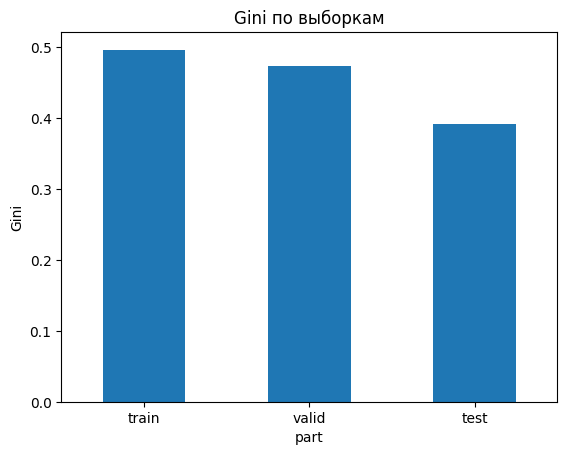

In [53]:
overfit_check.set_index('part')['Gini'].plot(kind='bar', rot=0, title='Gini по выборкам'); plt.ylabel('Gini'); plt.show()

**Вывод**

- Разрыв между train и valid небольшой - значит сильного переобучения нет.
  Это ожидаемо: логистическая регрессия - простая модель с малым числом параметров, плюс включена регуляризация.
- Небольшое падение качества на test по сравнению с valid связано не только с переобучением, но и с тем,
  что test - это **более поздний период времени**. Состав машин и рыночные цены со временем меняются,
  поэтому часть просадки объясняется дрейфом данных, а не заучиванием обучающей выборки.
- Если бы train сильно опережал valid (например 0.4 против 0.2), это был бы явный признак переобучения,
  и стоило бы уменьшить `C` или сократить число признаков

## Задание 11. Precision, Recall, F1 и AUC PR

Precision, Recall и F1 считаются по жестким меткам, поэтому сначала переводим вероятности в классы по порогу.

- **Precision** - какая доля предсказанных "лимонов" действительно лимоны;
- **Recall** - какую долю настоящих лимонов мы нашли;
- **F1** - их гармоническое среднее.

**AUC PR** (average precision) агрегирует precision и recall по всем возможным порогам.
Считаем так: сортируем объекты по убыванию вероятности, накопительно считаем precision и recall
и суммируем `precision * (прирост recall)`

In [54]:
def confusion_counts(y_true, y_pred):
    y, p = np.asarray(y_true), np.asarray(y_pred)
    return ((y == 1) & (p == 1)).sum(), ((y == 0) & (p == 1)).sum(), ((y == 1) & (p == 0)).sum()

In [55]:
def precision_custom(y_true, y_pred):
    tp, fp, _ = confusion_counts(y_true, y_pred)
    return tp / (tp + fp) if tp + fp else 0

def recall_custom(y_true, y_pred):
    tp, _, fn = confusion_counts(y_true, y_pred)
    return tp / (tp + fn) if tp + fn else 0

def f1_custom(y_true, y_pred):
    p, r = precision_custom(y_true, y_pred), recall_custom(y_true, y_pred)
    return 2 * p * r / (p + r) if p + r else 0

In [56]:
def auc_pr_custom(y_true, proba):
    order = np.argsort(-np.asarray(proba))
    y = np.asarray(y_true)[order]
    tp, fp = np.cumsum(y), np.cumsum(1 - y)
    precision, recall = tp / (tp + fp), tp / y.sum()
    return float(np.sum(np.diff(np.concatenate([[0.0], recall])) * precision))

Важный момент про порог. Класс "лимон" редкий (около 12%), поэтому модель почти никогда не выдает
вероятность выше 0.5 - при стандартном пороге она предскажет всем нули, и Precision/Recall/F1 будут равны нулю.
Это не ошибка реализации, а следствие дисбаланса классов.

Поэтому для демонстрации возьмем порог по квантилю: такой, при котором доля предсказанных единиц
равна реальной доле лимонов в выборке. Оба варианта покажем ниже

In [57]:
proba_best = best_model.predict_proba(X_test_ext)[:, 1]
pred_05 = (proba_best >= 0.5).astype(int)
threshold_q = np.quantile(proba_best, 1 - y_test.mean())
pred_best = (proba_best >= threshold_q).astype(int)
round(threshold_q, 4), pred_05.mean(), pred_best.mean()

(np.float64(0.2706),
 np.float64(0.049341595662277304),
 np.float64(0.12261812548412084))

Сверяем свои реализации со sklearn

In [58]:
pd.DataFrame([{'metric': 'Precision', 'custom': precision_custom(y_test, pred_best), 'sklearn': precision_score(y_test, pred_best, zero_division=0)},
              {'metric': 'Recall', 'custom': recall_custom(y_test, pred_best), 'sklearn': recall_score(y_test, pred_best)},
              {'metric': 'F1', 'custom': f1_custom(y_test, pred_best), 'sklearn': f1_score(y_test, pred_best)},
              {'metric': 'AUC PR', 'custom': auc_pr_custom(y_test, proba_best), 'sklearn': average_precision_score(y_test, proba_best)}]).round(6)

,metric,custom,sklearn
0,Precision,0.297220,0.297220
1,Recall,0.297220,0.297220
2,F1,0.297220,0.297220
3,AUC PR,0.348405,0.348405


Значения совпадают со sklearn, значит формулы реализованы верно

Теперь сравним все алгоритмы на **test** по AUC PR. AUC PR подходит лучше ROC AUC при сильном дисбалансе классов:
он показывает качество именно на редком классе и не завышается за счет большого числа легких отрицательных примеров

In [59]:
final_models = {'LogisticRegression (best)': best_model,
                'LogisticRegression (base)': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE).fit(X_train_ext, y_train),
                'GaussianNB': GaussianNB().fit(X_train_ext, y_train),
                'KNN': KNeighborsClassifier(n_neighbors=50, n_jobs=-1).fit(X_train_ext, y_train),
                'MyLogisticRegression': MyLogisticRegression(lr=1.0, epochs=100, batch_size=64, random_state=RANDOM_STATE).fit(X_train_ext, y_train)}

In [60]:
test_comparison = pd.DataFrame([{'model': name, 'AUC_PR': auc_pr_custom(y_test, m.predict_proba(X_test_ext)[:, 1]), 'Gini': gini_custom(y_test, m.predict_proba(X_test_ext)[:, 1])}
                                for name, m in final_models.items()]).sort_values('AUC_PR', ascending=False).reset_index(drop=True)
test_comparison.round(4)

,model,AUC_PR,Gini
0,KNN,0.4217,0.4123
1,LogisticRegression (best),0.3484,0.3919
2,LogisticRegression (base),0.2969,0.3738
3,MyLogisticRegression,0.1851,0.3318
4,GaussianNB,0.1787,0.3219


In [61]:
baseline_ap = y_test.mean()
print('Доля класса 1 в test (baseline для AUC PR):', round(baseline_ap, 4))

Доля класса 1 в test (baseline для AUC PR): 0.1226


Базовый уровень AUC PR для случайной модели равен доле положительного класса (около 0.12).
Все, что выше - реальный сигнал модели

## Задание 12. Какую метрику по жестким меткам выбрать

Посмотрим, как меняются precision, recall и F1 при разных порогах

Диапазон берем низкий (от 0.02 до 0.5): раз положительный класс редкий, оптимальный порог заведомо сильно ниже 0.5

In [62]:
thresholds = pd.DataFrame([{'threshold': round(t, 2), 'Precision': precision_custom(y_test, (proba_best >= t).astype(int)),
                            'Recall': recall_custom(y_test, (proba_best >= t).astype(int)),
                            'F1': f1_custom(y_test, (proba_best >= t).astype(int))} for t in np.arange(0.02, 0.52, 0.02)])
thresholds.round(4)

,threshold,Precision,Recall,F1
0,0.02,0.1225,0.9987,0.2183
1,0.04,0.1315,0.9690,0.2315
2,0.06,0.1538,0.8756,0.2617
3,0.08,0.1758,0.7476,0.2846
4,0.10,0.1949,0.6368,0.2984
5,0.12,0.2138,0.5496,0.3079
6,0.14,0.2270,0.4798,0.3082
7,0.16,0.2376,0.4318,0.3065
8,0.18,0.2468,0.3932,0.3033
9,0.20,0.2536,0.3588,0.2971


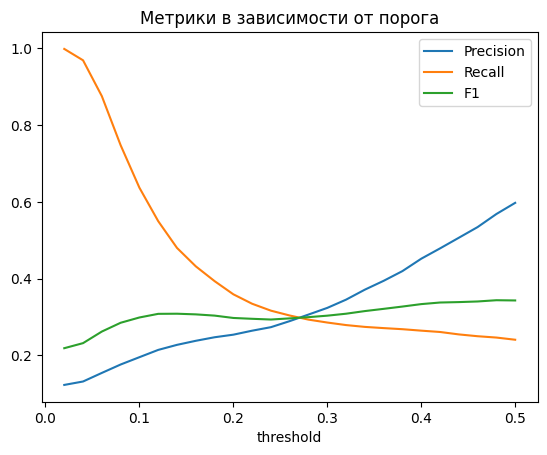

In [63]:
thresholds.set_index('threshold')[['Precision', 'Recall', 'F1']].plot(title='Метрики в зависимости от порога'); plt.show()

In [64]:
best_threshold = thresholds.sort_values('F1', ascending=False).iloc[0]
best_threshold.round(4)

threshold    0.4800
Precision    0.5682
Recall       0.2461
F1           0.3434
Name: 23, dtype: float64

**Почему Accuracy не подходит.** Лимонов всего около 12%. Модель, которая всегда предсказывает "хорошая машина",
даст accuracy ~88% и при этом будет абсолютно бесполезной - не найдет ни одного лимона

In [65]:
pd.DataFrame([{'model': 'Всегда предсказываем 0', 'Accuracy': (y_test == 0).mean(), 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0},
              {'model': 'Модель, порог 0.5', 'Accuracy': (pred_05 == y_test).mean(), 'Precision': precision_custom(y_test, pred_05), 'Recall': recall_custom(y_test, pred_05), 'F1': f1_custom(y_test, pred_05)},
              {'model': f'Модель, порог {round(best_threshold["threshold"], 2)}', 'Accuracy': ((proba_best >= best_threshold['threshold']).astype(int) == y_test).mean(),
               'Precision': best_threshold['Precision'], 'Recall': best_threshold['Recall'], 'F1': best_threshold['F1']}]).round(4)

,model,Accuracy,Precision,Recall,F1
0,Всегда предсказываем 0,0.8774,0.0000,0.0000,0.0000
1,"Модель, порог 0.5",0.8870,0.5973,0.2404,0.3428
2,"Модель, порог 0.48",0.8846,0.5682,0.2461,0.3434


**Вывод: выбираем F1 (а точнее - F-beta со сдвигом в сторону Recall).**

Рассуждение по смыслу задачи:

- **Ошибка FN** (купили лимон, а модель сказала "все хорошо") стоит дорого: дилер получает машину с дефектами,
  теряет деньги на ремонте и перепродаже
- **Ошибка FP** (модель предупредила о риске, а машина оказалась нормальной) стоит дешево: просто не купили
  один лот из тысяч доступных на аукционе
- значит, **Recall важнее Precision**. Но и один Recall брать нельзя: его легко довести до 1.0, объявив лимонами
  все машины подряд - тогда бизнес просто перестанет покупать.

Поэтому нужен баланс с перекосом в сторону Recall - это **F-beta с beta > 1** (например F2).
Если же нужна одна простая и понятная метрика, берем **F1**: он держит баланс и, в отличие от accuracy,
не дает себя обмануть дисбалансом классов.

Отдельно отмечу: порог 0.5 здесь не оптимален. По таблице выше видно, что максимум F1 достигается при
меньшем пороге - это логично, раз положительный класс редкий. На практике порог подбирают под бизнес-ограничение